Discharge analysis

In [67]:
import numpy as np
import pandas as pd 
import json
from hbv_bmi_project import HBV_Bmi
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats

### Part 1 : flow duration curves

In [68]:
grdc_obs = pd.read_csv(
    '/Users/doriswong/Documents/ENVM1502/teaching-materials/Assignments/6336500_Q_Day.Cmd.txt',
    encoding='latin-1',
    sep=';',
    skiprows=36,
    index_col=0,
    parse_dates=True,
    usecols=[0, 2],
)
grdc_obs.index.name = 'date'
grdc_obs.columns = ['Observations from GRDC']
grdc_obs['Observations from GRDC'] = grdc_obs['Observations from GRDC'].replace(-999, np.nan) #remove nan values


In [69]:
def exceedance_probability(Q):
    """Sort and rank discharge to compute exceedance probability."""
    Q_sorted = np.sort(Q.dropna())[::-1]  # sort descending
    n = len(Q_sorted)
    prob = np.arange(1, n + 1) / (n + 1)  # Weibull plotting position
    return prob, Q_sorted

In [70]:
q = grdc_obs['Observations from GRDC']
prob, Q_sorted = exceedance_probability(q)


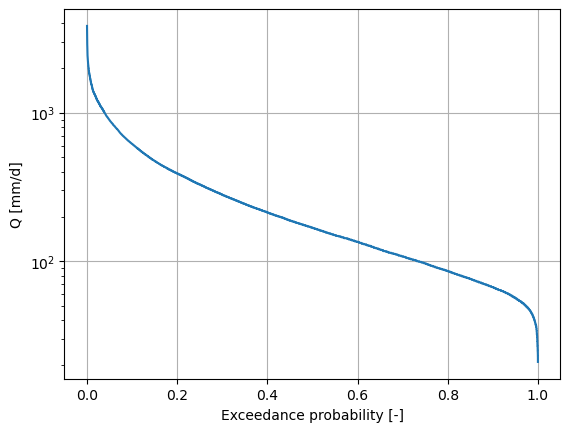

In [51]:
plt.plot(prob, Q_sorted)
plt.yscale('log')
plt.ylabel('Q [mm/d]')
plt.xlabel('Exceedance probability [-]')
plt.grid()

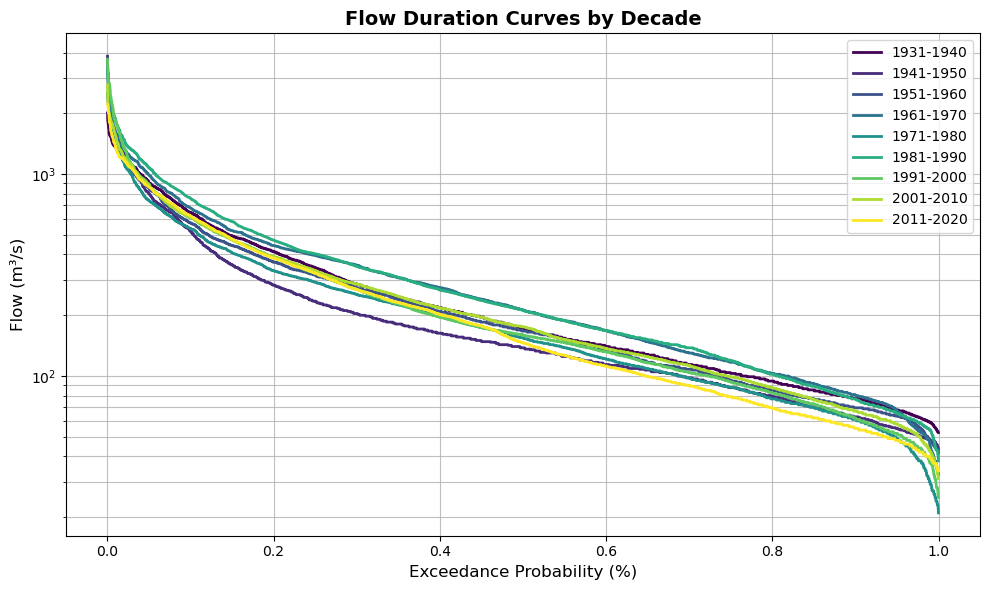

In [55]:
# Prepare decades
decades = {}
for decade_start in range(1931, 2021, 10):
    decade_end = decade_start + 9
    mask = (grdc_obs.index.year >= decade_start) & (grdc_obs.index.year <= decade_end)
    if len(grdc_obs[mask]) > 0:  # Only add if data exists
        decades[f"{decade_start}-{decade_end}"] = grdc_obs[mask]

# Create FDC plot
fig, ax = plt.subplots(figsize=(10, 6))

# Colors for different decades
colors = plt.cm.viridis(np.linspace(0, 1, len(decades)))

# Plot FDC for each decade
for (label, df_decade), color in zip(decades.items(), colors):
    q = df_decade.iloc[:, 0]  # Assuming flow is first column
    prob, Q_sorted = exceedance_probability(q)
    ax.plot(prob, Q_sorted, label=label, linewidth=2, color=color)

# Formatting
ax.set_xlabel('Exceedance Probability (%)', fontsize=12)
ax.set_ylabel('Flow (m³/s)', fontsize=12)
ax.set_title('Flow Duration Curves by Decade', fontsize=14, fontweight='bold')
ax.set_yscale('log')  # Log scale for flow (typical for FDCs)
ax.grid(True, alpha=0.8, which='both')
ax.legend(loc='best', fontsize=10)

plt.tight_layout()
plt.show()

In [57]:
# Calculate and print 10th and 90th percentiles for each decade
print("=" * 60)
print(f"{'Decade':<15} {'10th Percentile (Q90)':<25} {'90th Percentile (Q10)':<25}")
print("=" * 60)

for decade_start in range(1931, 2021, 10):
    decade_end = decade_start + 9
    mask = (grdc_obs.index.year >= decade_start) & (grdc_obs.index.year <= decade_end)
    df_decade = grdc_obs[mask]
    
    if len(df_decade) > 0:
        q = df_decade.iloc[:, 0].dropna()
        
        # Calculate percentiles
        # Note: 10th percentile = Q90 (exceeded 90% of the time - low flow)
        #       90th percentile = Q10 (exceeded 10% of the time - high flow)
        p10 = np.percentile(q, 10)   # Q90 - low flow
        p90 = np.percentile(q, 90)   # Q10 - high flow
        
        print(f"{decade_start}-{decade_end:<8} {p10:>20.2f} m³/s {p90:>20.2f} m³/s")
    else:
        print(f"{decade_start}-{decade_end:<8} {'No data':>20} {'No data':>20}")

print("=" * 60)

Decade          10th Percentile (Q90)     90th Percentile (Q10)    
1931-1940                    77.40 m³/s               645.00 m³/s
1941-1950                    62.80 m³/s               522.60 m³/s
1951-1960                    69.60 m³/s               572.00 m³/s
1961-1970                    80.19 m³/s               679.00 m³/s
1971-1980                    61.00 m³/s               537.60 m³/s
1981-1990                    77.00 m³/s               756.00 m³/s
1991-2000                    62.00 m³/s               608.60 m³/s
2001-2010                    67.00 m³/s               614.00 m³/s
2011-2020                    55.00 m³/s               620.80 m³/s


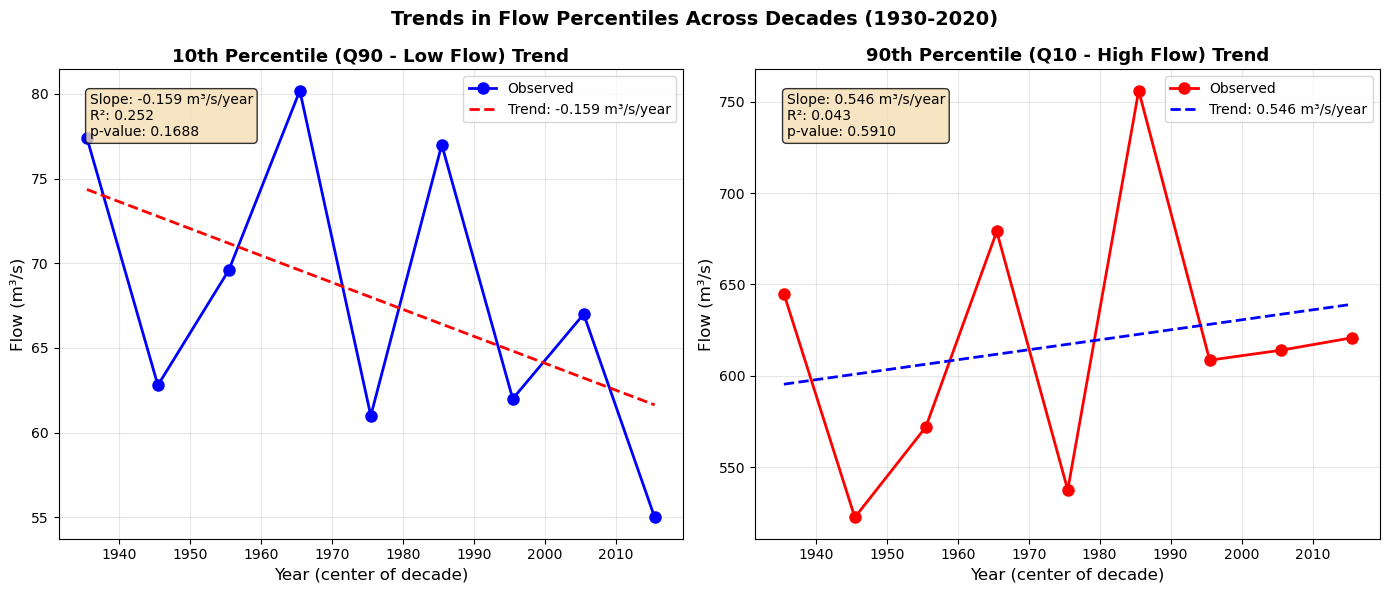

In [65]:
# Calculate percentiles for each decade
decades = []
p10_values = []  # 10th percentile (low flows - Q90)
p90_values = []  # 90th percentile (high flows - Q10)
years_center = []  # Center year of each decade for plotting

for decade_start in range(1931, 2021, 10):
    decade_end = decade_start + 9
    mask = (grdc_obs.index.year >= decade_start) & (grdc_obs.index.year <= decade_end)
    df_decade = grdc_obs[mask]
    
    if len(df_decade) > 0:
        q = df_decade.iloc[:, 0].dropna()
        
        decades.append(f"{decade_start}-{decade_end}")
        p10_values.append(np.percentile(q, 10))
        p90_values.append(np.percentile(q, 90))
        years_center.append(decade_start + 4.5)  # Center of the decade

# Convert to numpy arrays for calculations
years = np.array(years_center)
p10 = np.array(p10_values)
p90 = np.array(p90_values)

# Calculate trends (linear regression)
slope_p10, intercept_p10, r_value_p10, p_value_p10, std_err_p10 = stats.linregress(years, p10)
slope_p90, intercept_p90, r_value_p90, p_value_p90, std_err_p90 = stats.linregress(years, p90)

# Create figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Time vs 10th percentile (low flows)
ax1.plot(years, p10, 'o-', color='blue', linewidth=2, markersize=8, label='Observed')
ax1.plot(years, intercept_p10 + slope_p10 * years, 'r--', linewidth=2, 
         label=f'Trend: {slope_p10:.3f} m³/s/year')
ax1.set_xlabel('Year (center of decade)', fontsize=12)
ax1.set_ylabel('Flow (m³/s)', fontsize=12)
ax1.set_title('10th Percentile (Q90 - Low Flow) Trend', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10)

# Add statistical annotation
ax1.text(0.05, 0.95, f'Slope: {slope_p10:.3f} m³/s/year\nR²: {r_value_p10**2:.3f}\np-value: {p_value_p10:.4f}', 
         transform=ax1.transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8), fontsize=10)

# Plot 2: Time vs 90th percentile (high flows)
ax2.plot(years, p90, 'o-', color='red', linewidth=2, markersize=8, label='Observed')
ax2.plot(years, intercept_p90 + slope_p90 * years, 'b--', linewidth=2,
         label=f'Trend: {slope_p90:.3f} m³/s/year')
ax2.set_xlabel('Year (center of decade)', fontsize=12)
ax2.set_ylabel('Flow (m³/s)', fontsize=12)
ax2.set_title('90th Percentile (Q10 - High Flow) Trend', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=10)

# Add statistical annotation
ax2.text(0.05, 0.95, f'Slope: {slope_p90:.3f} m³/s/year\nR²: {r_value_p90**2:.3f}\np-value: {p_value_p90:.4f}',
         transform=ax2.transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8), fontsize=10)

plt.suptitle('Trends in Flow Percentiles Across Decades (1930-2020)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Part 2: Budyko framework 


In [105]:
# Build era5_data.csv from downloaded ERA5 NetCDF files (run after downloads finish)
import numpy as np
import pandas as pd
import xarray as xr
from pathlib import Path
import zipfile
import tempfile

# --- Locate ERA5 folder and files ---
candidate_dirs = [
    Path.cwd() / 'era5_raw',
    Path('/Users/doriswong/Documents/ENVM1502/teaching-materials/Main_project/era5_raw'),
    Path('/Users/doriswong/Documents/ENVM1502/teaching-materials/era5_raw'),
]
nc_dir = next((d for d in candidate_dirs if d.exists()), None)
if nc_dir is None:
    raise FileNotFoundError('Could not find era5_raw folder. Check download output path.')

nc_files = sorted(nc_dir.glob('*.nc'))
if not nc_files:
    raise FileNotFoundError(f'No .nc files found in {nc_dir}')

print(f'Found {len(nc_files)} files in: {nc_dir}')


def pick_var(ds, names):
    for n in names:
        if n in ds.data_vars:
            return n
    return None


def pick_time_name(ds):
    candidates = ['time', 'valid_time', 'forecast_time', 'initial_time0_hours']
    for c in candidates:
        if c in ds.coords or c in ds.dims:
            return c
    return None


def spatial_mean(da):
    dims = [d for d in ['latitude', 'longitude', 'lat', 'lon'] if d in da.dims]
    return da.mean(dim=dims, skipna=True) if dims else da


def open_netcdf_with_fallback(path):
    for eng in ['netcdf4', 'scipy', None]:
        try:
            if eng is None:
                return xr.open_dataset(path)
            return xr.open_dataset(path, engine=eng)
        except Exception:
            pass
    raise RuntimeError('Could not open with netcdf4/scipy/auto engines')


def open_era_dataset(path):
    """Open ERA file whether plain NetCDF or a ZIP archive containing NetCDF."""
    if zipfile.is_zipfile(path):
        with zipfile.ZipFile(path) as zf:
            members = [m for m in zf.namelist() if m.lower().endswith('.nc')]
            if not members:
                raise RuntimeError('zip archive contains no .nc member')
            data = zf.read(members[0])
        tmp = tempfile.NamedTemporaryFile(suffix='.nc', delete=False)
        tmp.write(data)
        tmp.flush()
        tmp.close()
        ds = open_netcdf_with_fallback(tmp.name)
        return ds, tmp.name

    ds = open_netcdf_with_fallback(path)
    return ds, None


rows = []
skipped = 0
used = 0
for f in nc_files:
    if f.stat().st_size == 0:
        print(f'Skipping {f.name}: empty file')
        skipped += 1
        continue

    tmp_path = None
    try:
        ds, tmp_path = open_era_dataset(f)
    except Exception as exc:
        print(f'Skipping {f.name}: cannot open as NetCDF ({exc})')
        skipped += 1
        continue

    try:
        with ds:
            time_name = pick_time_name(ds)
            if time_name is None:
                print(f'Skipping {f.name}: no time-like coordinate (expected time/valid_time)')
                skipped += 1
                continue

            t2m_name = pick_var(ds, ['t2m', '2m_temperature'])
            d2m_name = pick_var(ds, ['d2m', '2m_dewpoint_temperature'])
            ssrd_name = pick_var(ds, ['ssrd', 'surface_solar_radiation_downwards'])
            u10_name = pick_var(ds, ['u10', '10m_u_component_of_wind'])
            v10_name = pick_var(ds, ['v10', '10m_v_component_of_wind'])
            evap_name = pick_var(ds, ['pev', 'potential_evaporation', 'e', 'evaporation', 'total_evaporation'])

            required = [t2m_name, d2m_name, ssrd_name, u10_name, v10_name]
            if any(v is None for v in required):
                print(f'Skipping {f.name}: missing one or more required variables')
                skipped += 1
                continue

            t2m = spatial_mean(ds[t2m_name]).rename({time_name: 'time'}).to_series().sort_index()
            d2m = spatial_mean(ds[d2m_name]).rename({time_name: 'time'}).to_series().sort_index()
            ssrd = spatial_mean(ds[ssrd_name]).rename({time_name: 'time'}).to_series().sort_index()
            u10 = spatial_mean(ds[u10_name]).rename({time_name: 'time'}).to_series().sort_index()
            v10 = spatial_mean(ds[v10_name]).rename({time_name: 'time'}).to_series().sort_index()

            df = pd.DataFrame({
                'tmean': t2m,
                'd2m': d2m,
                'ssrd': ssrd,
                'u10': u10,
                'v10': v10,
            }).sort_index()

            df = df.dropna(subset=['tmean', 'd2m', 'ssrd', 'u10', 'v10'])

            inferred = pd.infer_freq(df.index)
            if inferred is None or inferred.upper() not in ['D', '24H']:
                df = df.resample('D').agg({
                    'tmean': 'mean',
                    'd2m': 'mean',
                    'ssrd': 'sum',
                    'u10': 'mean',
                    'v10': 'mean',
                })
                df = df.dropna(subset=['tmean', 'd2m', 'ssrd', 'u10', 'v10'])

            df['wind'] = np.sqrt(df['u10']**2 + df['v10']**2)
            df['tmean_c'] = df['tmean'] - 273.15
            df['d2m_c'] = df['d2m'] - 273.15
            df['Ea_kPa'] = 0.6108 * np.exp((17.27 * df['d2m_c']) / (df['d2m_c'] + 237.3))

            if evap_name is not None:
                evap = spatial_mean(ds[evap_name]).rename({time_name: 'time'}).to_series().sort_index()
                if inferred is None or inferred.upper() not in ['D', '24H']:
                    evap = evap.resample('D').sum(min_count=1)
                df['Ea_mm_day'] = (-evap.reindex(df.index) * 1000.0).clip(lower=0)
            else:
                df['Ea_mm_day'] = np.nan

            rows.append(df.reset_index().rename(columns={'time': 'date'}))
            used += 1
    finally:
        if tmp_path is not None:
            Path(tmp_path).unlink(missing_ok=True)

if not rows:
    raise RuntimeError('No usable data extracted from .nc files. Files are present but none had required variables/time.')

era5_data = pd.concat(rows, ignore_index=True)
era5_data = era5_data.sort_values('date').drop_duplicates(subset='date', keep='first')

out_csv = Path.cwd() / 'era5_data.csv'
era5_data.to_csv(out_csv, index=False)

print(f'Wrote {len(era5_data)} daily rows to: {out_csv}')
print(f'Used files: {used} | Skipped files: {skipped}')
print('Columns:', ', '.join(era5_data.columns))
era5_data.head()

Found 45 files in: /Users/doriswong/Documents/ENVM1502/teaching-materials/Main_project/era5_raw
Wrote 16437 daily rows to: /Users/doriswong/Documents/ENVM1502/teaching-materials/Main_project/era5_data.csv
Used files: 45 | Skipped files: 0
Columns: date, tmean, d2m, ssrd, u10, v10, wind, tmean_c, d2m_c, Ea_kPa, Ea_mm_day


,date,tmean,d2m,ssrd,u10,v10,wind,tmean_c,d2m_c,Ea_kPa,Ea_mm_day
0,1980-01-01 12:00:00,272.343201,268.911652,1.754128e+06,3.676905,0.037087,3.677092,-0.806793,-4.238342,0.446173,NaN
1,1980-01-02 12:00:00,272.594299,269.129974,1.696011e+06,3.144645,-3.439631,4.660457,-0.555695,-4.020020,0.453576,NaN
2,1980-01-03 12:00:00,271.691803,268.445770,1.693975e+06,1.958446,0.177675,1.966489,-1.458191,-4.704224,0.430732,NaN
3,1980-01-04 12:00:00,273.164001,272.175171,6.671952e+05,1.025172,3.605019,3.747951,0.014008,-0.974823,0.568802,NaN
4,1980-01-05 12:00:00,275.763031,274.949280,9.544287e+05,2.915635,1.841404,3.448434,2.613037,1.799286,0.695570,NaN


In [113]:
### current situation
# Load ERA5 data for evaporation calculation
era5_data = pd.read_csv('era5_data.csv')
era5_data['date'] = pd.to_datetime(era5_data['date'])
era5_data = era5_data.sort_values('date')
era5_data['month'] = era5_data['date'].dt.month

monthly_era5 = era5_data.groupby('month').mean(numeric_only=True).reset_index()

# Function to calculate Penman-Monteith ET0 (mm/day)
def penman_monteith(T_mean, T_max, T_min, u2, ea, Rs):
    """
    T_mean, T_max, T_min : °C
    u2                   : wind speed at 2m height (m/s)
    ea                   : actual vapour pressure (kPa)
    Rs                   : incoming solar radiation (MJ/m²/day)
    Returns ET0 in mm/day
    """
    def sat_vp(T):
        return 0.6108 * np.exp(17.27 * T / (T + 237.3))

    es = (sat_vp(T_max) + sat_vp(T_min)) / 2
    delta = 4098 * sat_vp(T_mean) / (T_mean + 237.3) ** 2

    gamma = 0.665e-3 * 101.3
    vpd = es - ea
    Rn = 0.77 * Rs

    ET0 = (0.408 * delta * Rn + gamma * (900 / (T_mean + 273)) * u2 * vpd) / \
          (delta + gamma * (1 + 0.34 * u2))
    return ET0

# Use Ea_kPa from parser if available, otherwise derive from dewpoint in °C
if 'Ea_kPa' in monthly_era5.columns:
    monthly_era5['ea'] = monthly_era5['Ea_kPa']
else:
    if 'd2m_c' in monthly_era5.columns:
        d2m_c_for_ea = monthly_era5['d2m_c']
    else:
        d2m_c_for_ea = monthly_era5['d2m'] - 273.15
    monthly_era5['ea'] = 0.6108 * np.exp(17.27 * d2m_c_for_ea / (d2m_c_for_ea + 237.3))

# Ensure mean temperature in °C
if 'tmean_c' in monthly_era5.columns:
    monthly_era5['tmean_pm'] = monthly_era5['tmean_c']
else:
    monthly_era5['tmean_pm'] = monthly_era5['tmean'] - 273.15

# Convert radiation to MJ/m²/day
# If parser came from hourly/sub-daily source, ssrd was daily J/m² total -> multiply 1e-6.
monthly_era5['Rs'] = monthly_era5['ssrd'] * 1e-6

# Derive T_max and T_min from ERA5 columns if available; otherwise approximate from T_mean
if 'tmax' in monthly_era5.columns and 'tmin' in monthly_era5.columns:
    T_max_hist = monthly_era5['tmax']
    T_min_hist = monthly_era5['tmin']
else:
    T_max_hist = monthly_era5['tmean_pm'] + 5
    T_min_hist = monthly_era5['tmean_pm'] - 5

monthly_era5['ET0'] = penman_monteith(
    monthly_era5['tmean_pm'], T_max_hist, T_min_hist,
    monthly_era5['wind'], monthly_era5['ea'], monthly_era5['Rs']
)

monthly_era5['ET_mm'] = monthly_era5['ET0'] * 30
et_monthly = monthly_era5.set_index('month')['ET_mm']

print('Historic ET0 (mm/month):')
print(et_monthly)
print(monthly_era5.shape)
print(f'Annual ET0 historic: {et_monthly.sum():.2f} mm/year')


Historic ET0 (mm/month):
month
1      24.093840
2      37.452640
3      60.640911
4      88.819932
5     105.726937
6     120.207699
7     131.744908
8     120.866368
9      90.759137
10     58.396941
11     32.202616
12     21.954115
Name: ET_mm, dtype: float64
(12, 16)
Annual ET0 historic: 892.87 mm/year


In [107]:
## analytical solution
def budyko_1948(EpP):
    EaP = np.sqrt(EpP * np.tanh(1/EpP) * (1 - np.exp(- EpP)))
    return EaP

x_vals = np.linspace(0.1, 5, 50)
energy_lim = np.linspace(0, 1, 10)
water_lim = np.linspace(1, 5, 40)
budyko = budyko_1948(x_vals)

In [87]:
## Daily Monte Carlo setup for hbv_bmi_project using stitched daily CSV inputs
from pathlib import Path
import pandas as pd
import numpy as np
import xarray as xr
from hbv_bmi_project import HBV_Bmi

# Explicit periods
start_spinup = pd.Timestamp('1980-01-01')
end_spinup = pd.Timestamp('1981-12-31')
start_cal = pd.Timestamp('1982-01-01')
end_cal = pd.Timestamp('2015-12-31')
start_val = pd.Timestamp('2016-01-01')
end_val = pd.Timestamp('2025-12-31')

start_mc = start_spinup
end_mc = end_cal

base_path = Path('/Users/doriswong/Documents/ENVM1502/teaching-materials/Main_project')
shape_area_local = float(globals().get('shape_area', 28191724718.0))
grdc_path_local = Path('/Users/doriswong/Documents/ENVM1502/teaching-materials/Assignments/6336500_Q_Day.Cmd.txt')

# Read stitched daily forcing CSVs (1980-2025), then clip to model windows
precip_daily_all = pd.read_csv(base_path / 'ERA5_daily_precip_1980-2025.csv')
evap_daily_all = pd.read_csv(base_path / 'ERA5_daily_evap_1980-2025.csv')
temp_daily_all = pd.read_csv(base_path / 'ERA5_daily_temp_1980-2025.csv')

for frame in (precip_daily_all, evap_daily_all, temp_daily_all):
    frame['time'] = pd.to_datetime(frame['system:index'].astype(str), format='%Y%m%d')

precip_daily_all = precip_daily_all.set_index('time')
evap_daily_all = evap_daily_all.set_index('time')
temp_daily_all = temp_daily_all.set_index('time')

# Convert sentinel to NaN
precip_daily_all['total_precipitation_daily'] = pd.to_numeric(precip_daily_all['total_precipitation_daily'], errors='coerce').replace(-9999, np.nan)
evap_daily_all['total_evaporation_daily'] = pd.to_numeric(evap_daily_all['total_evaporation_daily'], errors='coerce').replace(-9999, np.nan)

daily_forcing = pd.DataFrame(index=pd.date_range(start_mc, end_mc, freq='D'))
daily_forcing['precip_m_day'] = precip_daily_all['total_precipitation_daily'].reindex(daily_forcing.index)
daily_forcing['evap_m_day'] = evap_daily_all['total_evaporation_daily'].reindex(daily_forcing.index)

# Fill occasional gaps in forcing
daily_forcing['precip_m_day'] = daily_forcing['precip_m_day'].interpolate(limit_direction='both')
daily_forcing['evap_m_day'] = daily_forcing['evap_m_day'].interpolate(limit_direction='both')

# Convert forcing to model units
daily_forcing['P'] = daily_forcing['precip_m_day'] * 1000.0
daily_forcing['Ea'] = (-daily_forcing['evap_m_day']).clip(lower=0) * 1000.0


In [116]:
# Decadal means for Budyko-style water partitioning (using Ea, P, Q)
q_m3s = grdc_obs['Observations from GRDC'].rename('Q_m3s')

# Convert Q from m3/s to mm/day over basin area
q_mm_day = (q_m3s * 86400.0 / shape_area_local) * 1000.0
q_mm_day = q_mm_day.rename('Q')

budyko_daily = pd.concat([daily_forcing[['P', 'Ea']], q_mm_day], axis=1).dropna()
budyko_daily = budyko_daily[budyko_daily['P'] > 0].copy()

budyko_daily['year'] = budyko_daily.index.year
budyko_daily['decade_start'] = (budyko_daily['year'] // 10) * 10

means = budyko_daily.groupby('decade_start')[['P', 'Ea', 'Q']].mean()
means['Ea/P'] = means['Ea'] / means['P']
means['Ep/P'] = (et_monthly.sum()/365) / means['P']
means['closure_mm_day'] = means['P'] - means['Ea'] - means['Q']
means['Q/P'] = means['Q'] / means['P']
means['Stress_index'] = means['Ea/P'] / means['Ep/P']
means.index = means.index.astype(str) + 's'

print('Decadal means (mm/day) and ratios for Budyko plotting:')
means.round(4)

Decadal means (mm/day) and ratios for Budyko plotting:


,P,Ea,Q,Ea/P,Ep/P,closure_mm_day,Q/P,Stress_index
decade_start,,,,,,,,
1980s,2.8652,1.6907,1.0729,0.5901,0.8538,0.1016,0.3745,0.6912
1990s,2.6380,1.7578,0.8199,0.6663,0.9273,0.0603,0.3108,0.7186
2000s,2.6601,1.8021,0.8657,0.6775,0.9196,-0.0078,0.3254,0.7367
2010s,2.6135,1.7710,0.8054,0.6776,0.9360,0.0371,0.3082,0.7240


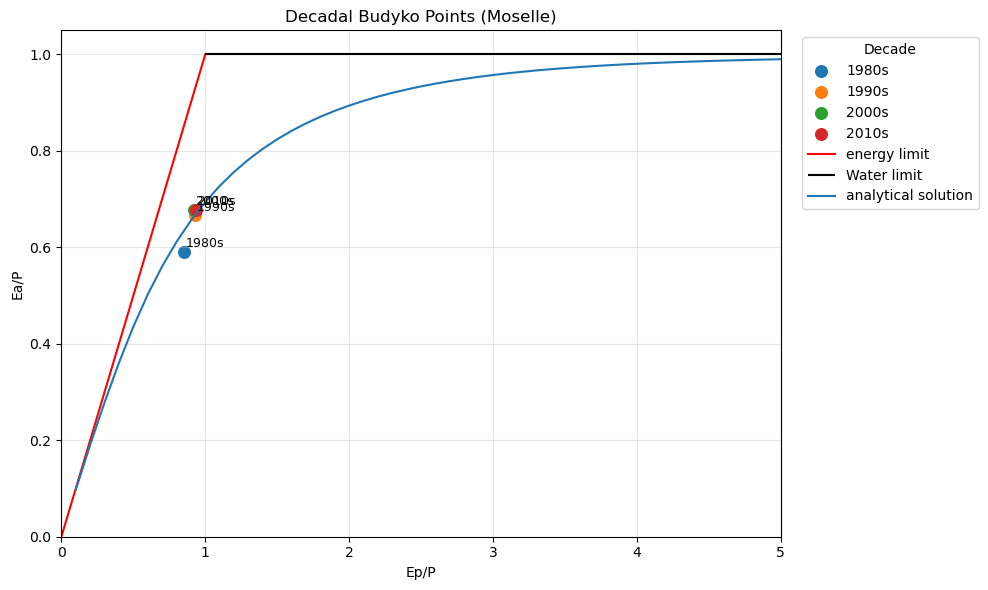

In [115]:
# Plot one point per decade in Budyko-style partition space (Q/P vs Ea/P)
fig, ax = plt.subplots(figsize=(10, 6))

x_vals = np.linspace(0.1, 5, 50)
energy_lim = np.linspace(0, 1, 10)
water_lim = np.linspace(1, 5, 40)
budyko = budyko_1948(x_vals)


for i, (label, row) in enumerate(means.iterrows()):
    ax.scatter(row['Ep/P'], row['Ea/P'], s=70, label=label)
    ax.text(row['Ep/P'] + 0.01, row['Ea/P'] + 0.01, label, fontsize=9)
    
plt.plot(energy_lim, energy_lim, label = 'energy limit', color = 'r')
plt.hlines(y = 1, xmin = 1, xmax = 5, label = 'Water limit', color = 'k')
plt.plot(x_vals, budyko, label = 'analytical solution')

ax.set_xlabel('Ep/P')
ax.set_ylabel('Ea/P')
ax.set_title('Decadal Budyko Points (Moselle)')
ax.set_xlim(0, 5)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
ax.legend(title='Decade', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()